# Train LFW Many People Many Images

Representative role: `many_people_many_images`.

This notebook processes LFW with the `40 x 25` preset after MTCNN filtering, splits train/test before saving, then trains `PCA + KNN` and `PCA + SVM` from the persisted split.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if not (ROOT / "src").exists():
    raise RuntimeError("Could not locate repo root containing 'src'.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml')

In [2]:
import pandas as pd

from src.process import process_lfw_dataset
from src.pipelines import train_pca_knn, train_pca_svm
from src.utils import compare_models, plot_confusion_matrix, plot_explained_variance, save_metrics


## Training config

In [3]:
config = {
    "dataset_name": "lfw",
    "role": "many_people_many_images",
    "test_size": 0.2,
    "random_state": 42,
    "n_components": 20,
    "knn_k": 3,
    "knn_metric": "euclidean",
    "svm_C": 1.0,
    "svm_kernel": "linear",
    "svm_gamma": "scale",
    "svm_max_iter": 50,
}

pd.Series(config)


dataset_name                        lfw
role            many_people_many_images
test_size                           0.2
random_state                         42
n_components                         20
knn_k                                 3
knn_metric                    euclidean
svm_C                               1.0
svm_kernel                       linear
svm_gamma                         scale
svm_max_iter                         50
dtype: object

## Process dataset, split train/test, and save processed artifacts

In [4]:
processed = process_lfw_dataset(
    test_size=config["test_size"],
    random_state=config["random_state"],
    save_artifacts=True,
)

summary = processed["summary"]
label_names = processed["metadata"]["label_names"]
confusion_labels = label_names if len(label_names) <= 20 else None

X_train = processed["X_train"]
X_test = processed["X_test"]
y_train = processed["y_train"]
y_test = processed["y_test"]

pd.Series({
    "dataset_name": summary["dataset_name"],
    "role": config["role"],
    "samples_total": summary["samples_total"],
    "classes_total": summary["classes_total"],
    "train_shape": summary["train_shape"],
    "test_shape": summary["test_shape"],
    "stratify_used": summary["stratify_used"],
    "processed_dir": processed["output_dir"],
})


dataset_name                                                   lfw
role                                       many_people_many_images
samples_total                                                 1440
classes_total                                                   96
train_shape                                          [1152, 10304]
test_shape                                            [288, 10304]
stratify_used                                                 True
processed_dir    D:\HCMUTE_project\Math_for_ML\math_for_ml\data...
dtype: object

In [5]:
pd.Series({
    "subjects_before_filter": summary["filter_stats"]["subjects_before_filter"],
    "subjects_after_filter": summary["filter_stats"]["subjects_after_filter"],
    "samples_before_filter": summary["filter_stats"]["samples_before_filter"],
    "samples_after_filter": summary["filter_stats"]["samples_after_filter"],
    "dropped_subject_count": summary["dropped_subject_count"],
    "truncated_subject_count": summary["truncated_subject_count"],
})


subjects_before_filter      5749
subjects_after_filter         96
samples_before_filter      13233
samples_after_filter        1440
dropped_subject_count       5653
truncated_subject_count       85
dtype: int64

## Train PCA + KNN

In [6]:
knn_model = train_pca_knn(
    X_train,
    y_train,
    n_components=config["n_components"],
    k=config["knn_k"],
    metric=config["knn_metric"],
)

knn_eval = knn_model.evaluate(X_test, y_test)
pd.Series({
    "accuracy": knn_eval["accuracy"],
    "train_time": knn_eval["train_time"],
})


accuracy      0.052083
train_time    0.886064
dtype: float64

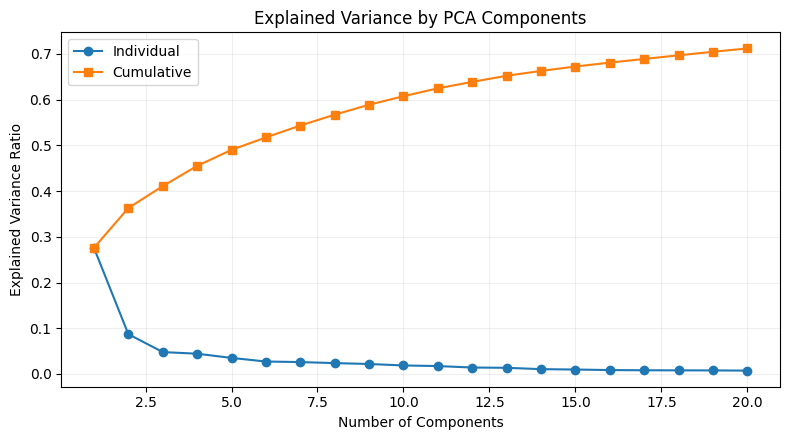

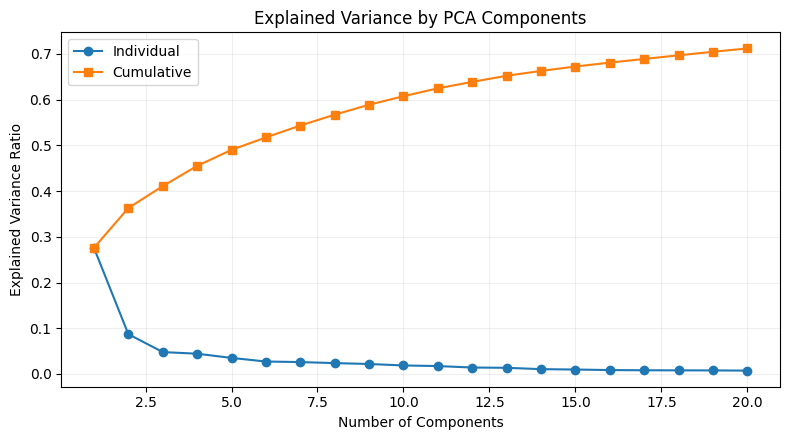

In [7]:
plot_explained_variance(knn_model.pca.explained_variance_ratio_)


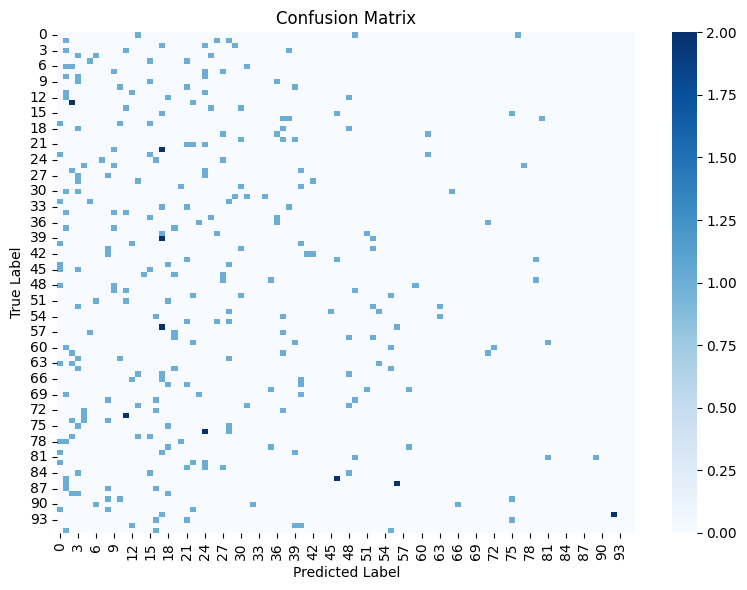

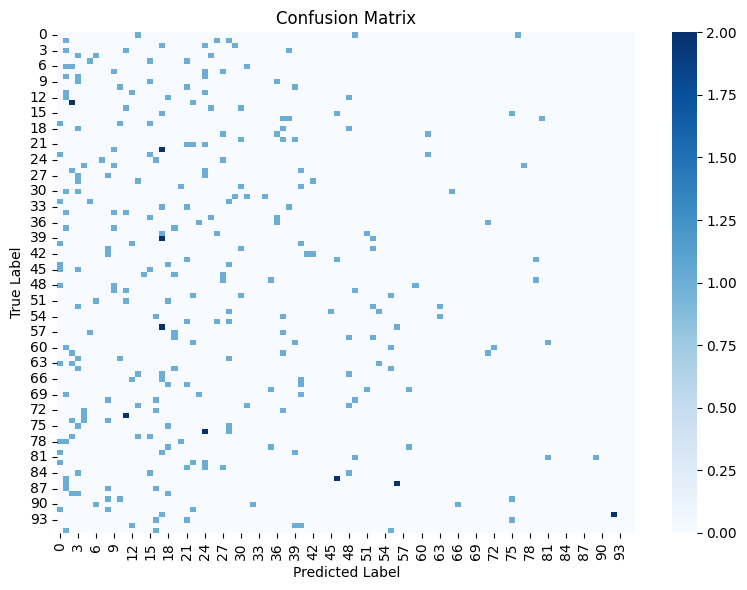

In [8]:
plot_confusion_matrix(knn_eval["confusion_matrix"], labels=confusion_labels)


## Train PCA + SVM

In [9]:
svm_model = train_pca_svm(
    X_train,
    y_train,
    n_components=config["n_components"],
    C=config["svm_C"],
    kernel=config["svm_kernel"],
    gamma=config["svm_gamma"],
    max_iter=config["svm_max_iter"],
)

svm_eval = svm_model.evaluate(X_test, y_test)
pd.Series({
    "accuracy": svm_eval["accuracy"],
    "train_time": svm_eval["train_time"],
})


accuracy       0.107639
train_time    33.710204
dtype: float64

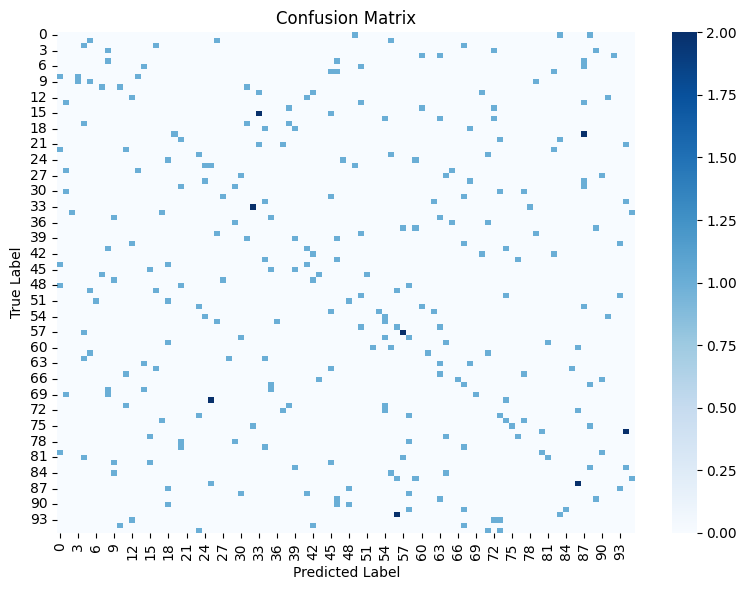

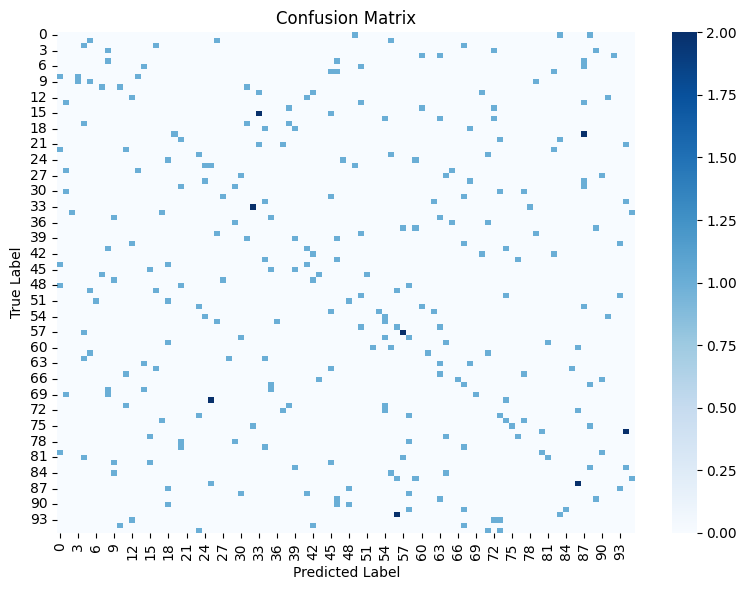

In [10]:
plot_confusion_matrix(svm_eval["confusion_matrix"], labels=confusion_labels)


## Compare and save metrics

In [11]:
comparison = compare_models(
    (knn_eval, "PCA+KNN"),
    (svm_eval, "PCA+SVM"),
)
comparison


         Accuracy  Precision  Recall  F1-Score  Train Time
Model                                                     
PCA+KNN    0.0521     0.0502  0.0521    0.0481       0.886
PCA+SVM    0.1076     0.1320  0.1076    0.1061      33.710


,Accuracy,Precision,Recall,F1-Score,Train Time
Model,,,,,
PCA+KNN,0.0521,0.0502,0.0521,0.0481,0.886
PCA+SVM,0.1076,0.1320,0.1076,0.1061,33.710


In [12]:
metrics_path = ROOT / "results" / "metrics" / "notebook_comparison_lfw_many_people_many_images.csv"
save_metrics(comparison, metrics_path)
metrics_path


[metrics] Đã lưu: D:\HCMUTE_project\Math_for_ML\math_for_ml\results\metrics\notebook_comparison_lfw_many_people_many_images.csv


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml/results/metrics/notebook_comparison_lfw_many_people_many_images.csv')

## Optional: save trained models

In [13]:
knn_model_path = ROOT / "webapp" / "saved_models" / "pca_knn_lfw_many_people_many_images_notebook.joblib"
svm_model_path = ROOT / "webapp" / "saved_models" / "pca_svm_lfw_many_people_many_images_notebook.joblib"

knn_model.save(knn_model_path)
svm_model.save(svm_model_path)
svm_model_path


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml/webapp/saved_models/pca_svm_lfw_many_people_many_images_notebook.joblib')